In [1]:
import pandas as pd
import numpy as np
file_path=pd.read_csv('D:\csv files\Advertising.csv')
df=pd.read_csv('D:\csv files\Advertising.csv')
print(df)
basic_inf=df.info()
head=df.head()
head
df.describe()

     Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                       68.95   35     61833.90                256.09   
1                       80.23   31     68441.85                193.77   
2                       69.47   26     59785.94                236.50   
3                       74.15   29     54806.18                245.89   
4                       68.37   35     73889.99                225.58   
..                        ...  ...          ...                   ...   
995                     72.97   30     71384.57                208.58   
996                     51.30   45     67782.17                134.42   
997                     51.63   51     42415.72                120.37   
998                     55.55   19     41920.79                187.95   
999                     45.01   26     29875.80                178.35   

                             Ad Topic Line            City  Male  \
0       Cloned 5thgeneration orchestration     Wrightbu

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


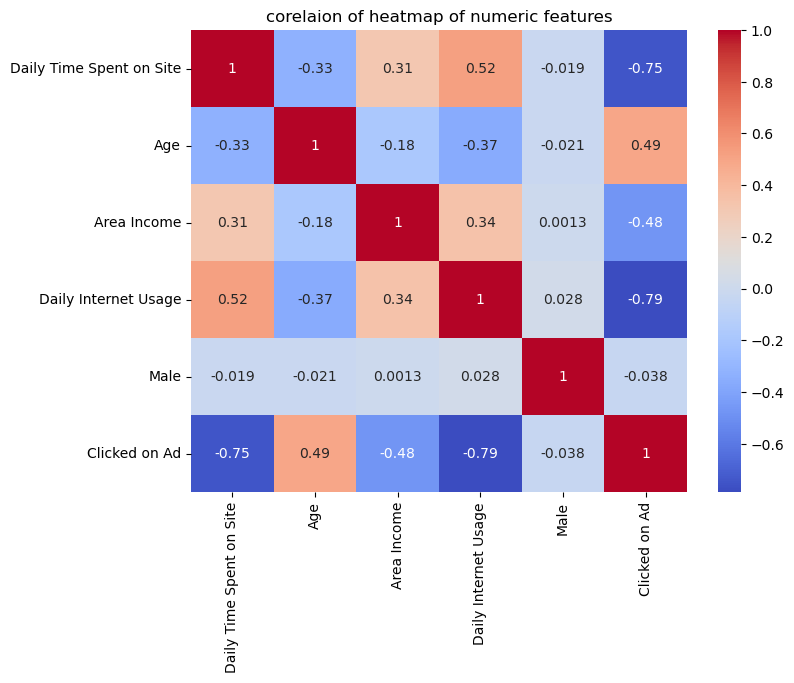

In [2]:
#heat map function for correlation features
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('corelaion of heatmap of numeric features')
plt.show()

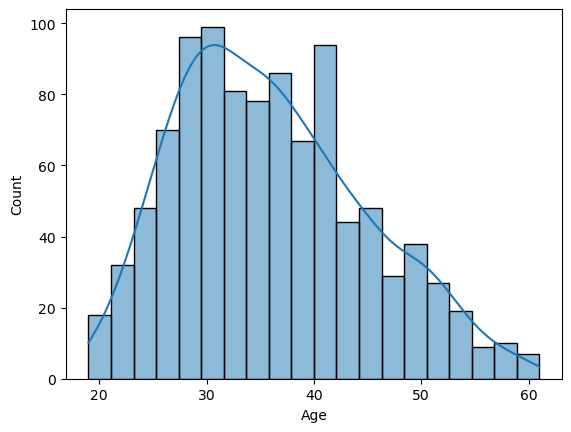

In [3]:
#Distribution of Age

plt.Figure(figsize=(6,4))

sns.histplot(df['Age'],bins=20,kde=True)



plt.xlabel('Age')

plt.show()

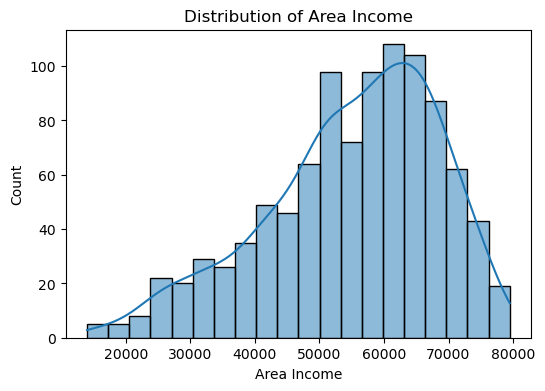

In [4]:
#Distribution of Area Income
plt.figure(figsize=(6,4))
sns.histplot(df['Area Income'],bins=20,kde=20)
plt.title('Distribution of Area Income')
plt.xlabel('Area Income')
plt.show()

In [5]:
#convert Timestamp to date time and extract new features
df['Timestamp']=pd.to_datetime(df['Timestamp'], format='%d-%m-%Y %H:%M')
df['Hour']=df['Timestamp'].dt.hour
df['Day']=df['Timestamp'].dt.dayofweek
df[['Timestamp', 'Hour', 'Day']].head()


,Timestamp,Hour,Day
0,2016-03-27 00:53:00,0,6
1,2016-04-04 01:39:00,1,0
2,2016-03-13 20:35:00,20,6
3,2016-01-10 02:31:00,2,6
4,2016-06-03 03:36:00,3,4


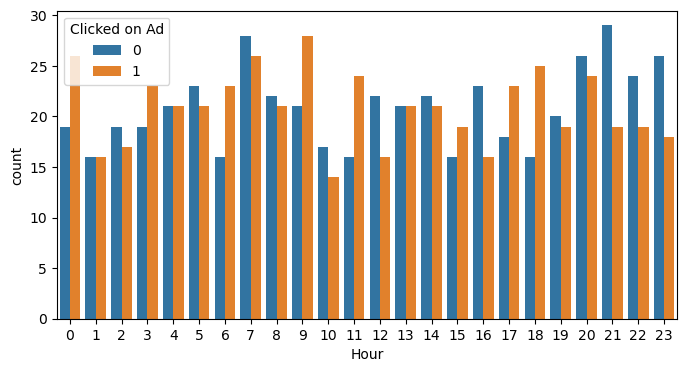

In [6]:
#clicked on Ad by hour
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.countplot(x='Hour', hue='Clicked on Ad', data=df)
plt.title=('Ad clicks by hour of Day')
plt.xlabel('Hour')
plt.ylabel('count')
plt.show()


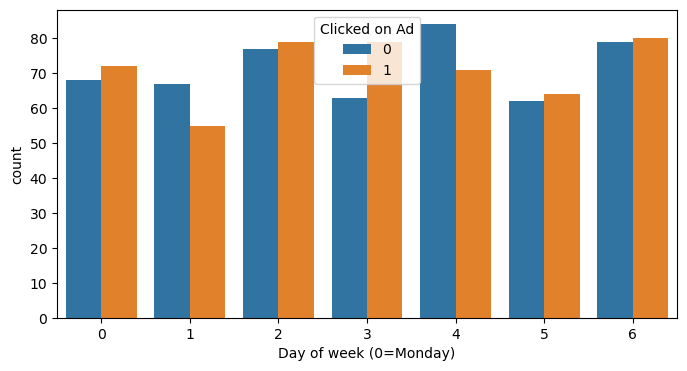

In [7]:
#clicked on Ad by Day of week
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(x='Day', hue='Clicked on Ad', data=df)
plt.title=str
plt.title=('Ad clicks on day of week')
plt.xlabel('Day of week (0=Monday)')
plt.ylabel('count')

plt.show()

In [8]:
print(type(plt.title))

<class 'str'>


In [12]:
#Define Feature set and target
x=df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male','Hour','Day']]
y=df['Clicked on Ad']
from sklearn.linear_model import LogisticRegression
logmodel=LogisticRegression(max_iter=1000)
logmodel.fit(x,y)
predictions=logmodel.predict(x) #predictions
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
conf_matrix=confusion_matrix(y,predictions)
accuracy=accuracy_score(y,predictions)
conf_matrix

array([[490,  10],
       [ 18, 482]])

In [10]:
print("Accuracy score:", accuracy)

Accuracy score: 0.972


In [13]:
class_report=classification_report(y,predictions)
print(class_report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       500
           1       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [14]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score
recall=recall_score(y,predictions)
print("Recall:", np.round(recall,2))
precision=precision_score(y,predictions)
print("precision:", np.round(precision,2))
f1=f1_score(y,predictions)
print("F1_score:",np.round(f1,2))
tn,fp,tn,tp=confusion_matrix(y,predictions).ravel()
specificity=tn/(tn+fp)
print("Specificity:", np.round(specificity,2))

Recall: 0.96
precision: 0.98
F1_score: 0.97
Specificity: 0.64


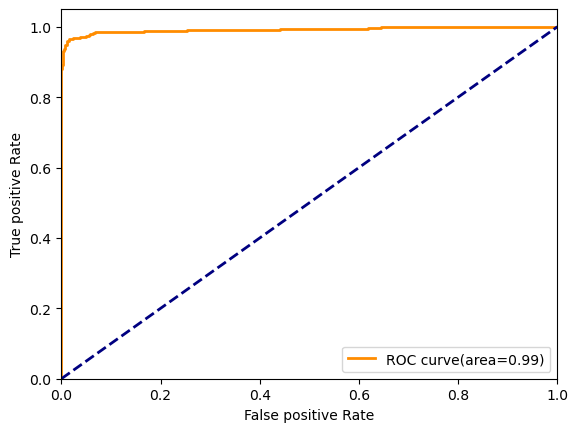

Auc score:<function roc_curve at 0x000002AD91D3D260>


In [15]:
from sklearn.metrics import roc_curve, auc
predictions=logmodel.predict(x)
y_pred_proba=logmodel.predict_proba(x) [ : , 1]
fpr,tpr,thresholds=roc_curve(y,y_pred_proba)
roc_auc=auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr, color='darkorange', lw=2, label='ROC curve(area=%0.2f)' % roc_auc)
plt.plot([0,1],[0,1], color='navy',lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.title=str
plt.title('Receiver operating characteristics')
plt.legend(loc="lower right")
plt.show()
print(f"Auc score:{roc_curve}")
         

In [16]:
#train  a logistic regression model
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
d=df[['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage']]
y=df['Clicked on Ad']
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
model=LogisticRegression(max_iter=1000)
model.fit(x_scaled,y)
weights=model.coef_[0]
bias=model.intercept_[0]
z=np.dot(x_scaled, weights)+bias
def sigmoid(z):
    return 1/(1+np.exp(-z))
probabilities=sigmoid(z)
predictions=(probabilities>=0.5).astype(int)
print("first 10 probabilities:\n",probabilities[ : 10])
print("\nfirst 10 predictions:\n",predictions[ : 10])
print("\n Actual values:\n",y.values[ : 10])

first 10 probabilities:
 [0.02090835 0.00925261 0.01815139 0.01051551 0.0241391  0.0499373
 0.01304126 0.99987801 0.00399483 0.07887948]

first 10 predictions:
 [0 0 0 0 0 0 0 1 0 0]

 Actual values:
 [0 0 0 0 0 0 0 1 0 0]


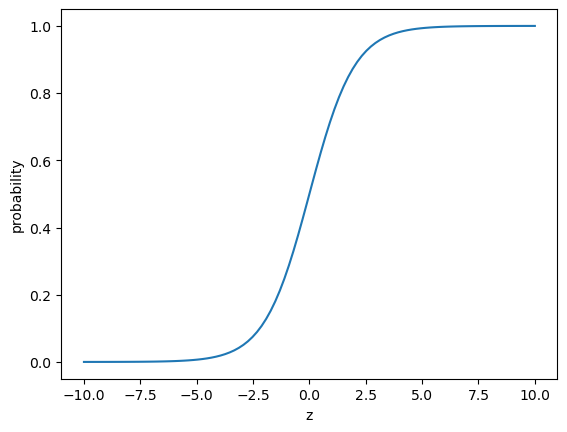

In [17]:
#Draw the Sigmoid curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
x=df[['Daily Time Spent on Site', 'Age','Area Income','Daily Internet Usage']]
y=df['Clicked on Ad']
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
model=LogisticRegression(max_iter=1000)
model.fit(x_scaled,y)
def sigmoid(z):
    return 1/(1+np.exp(-z))
z=np.dot(x_scaled, model.coef_[0])+model.intercept_[0]
probabilities=sigmoid(z)
predictions=(probabilities>=0.5).astype(int)
z_values=np.linspace(-10,10,100)
sig_values=sigmoid(z_values)
plt.figure()
plt.plot(z_values,sig_values)
plt.title('Sigmoid function(s-curve)')
plt.xlabel('z')
plt.ylabel('probability')
plt.show()